In [4]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

Task 1: Data Preparation
What we are doing: We manually load images from the Devnagari dataset folder using PIL (Python Imaging Library), convert them to grayscale NumPy arrays, normalize pixel values to [0, 1], and one-hot encode the labels so Keras can use them for multi-class classification.
Why PIL and Not Direct Keras Loading?

The Devnagari dataset is stored in a custom folder structure (digit_0/ through digit_9/ inside Train/ and Test/). Keras's built-in loaders such as mnist.load_data() only work for standard datasets. PIL gives us full control over loading, resizing, and converting images from any directory layout.



In [8]:
import zipfile
with zipfile.ZipFile('/content/Copy of devnagari digit.zip', 'r') as z:
    z.extractall('.')

Training set : (3000, 28, 28, 1)  |  Labels: (3000, 10)
Testing set  : (17000, 28, 28, 1)   |  Labels: (17000, 10)


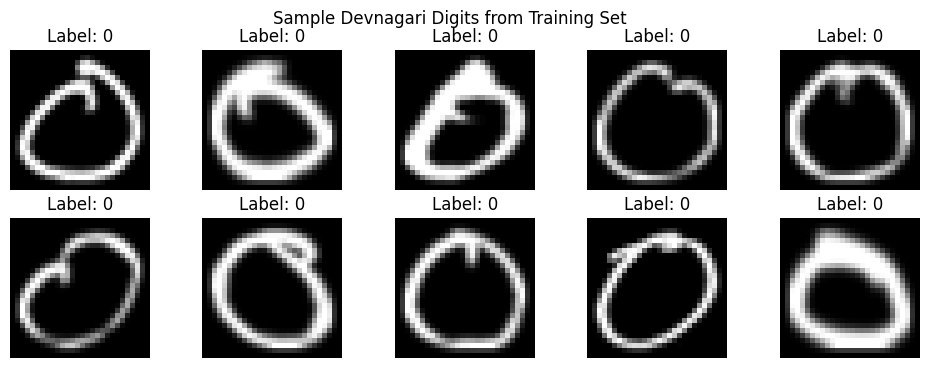

In [9]:
import os
import numpy as np

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from PIL import Image
import matplotlib.pyplot as plt

# ── Directory Paths ──────────────────────────────────────────────
train_dir = '/content/DevanagariHandwrittenDigitDataset/Test'
test_dir  = '/content/DevanagariHandwrittenDigitDataset/Train'

# ── Image Dimensions ─────────────────────────────────────────────
IMG_HEIGHT, IMG_WIDTH = 28, 28

# ── Helper Function ──────────────────────────────────────────────
def load_images_from_folder(folder):
    images, labels = [], []
    class_names = sorted(os.listdir(folder))          # ['digit_0', 'digit_1', ...]
    class_map   = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label      = class_map[class_name]
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            img = Image.open(img_path).convert('L')          # Grayscale
            img = img.resize((IMG_WIDTH, IMG_HEIGHT))        # 28x28
            img = np.array(img) / 255.0                     # Normalize [0,1]
            images.append(img)
            labels.append(label)
    return np.array(images), np.array(labels)

# ── Load Data ────────────────────────────────────────────────────
x_train, y_train = load_images_from_folder(train_dir)
x_test,  y_test  = load_images_from_folder(test_dir)

# ── Reshape for Keras: (samples, H, W, channels) ─────────────────
x_train = x_train.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)
x_test  = x_test.reshape(-1,  IMG_HEIGHT, IMG_WIDTH, 1)

# ── One-Hot Encode Labels ─────────────────────────────────────────
# e.g., label 3  →  [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
y_train = to_categorical(y_train, num_classes=10)
y_test  = to_categorical(y_test,  num_classes=10)

print(f'Training set : {x_train.shape}  |  Labels: {y_train.shape}')
print(f'Testing set  : {x_test.shape}   |  Labels: {y_test.shape}')

# ── Visualise Sample Images ───────────────────────────────────────
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f'Label: {np.argmax(y_train[i])}')
    plt.axis('off')
plt.suptitle('Sample Devnagari Digits from Training Set')
plt.show()



Explanation — Step by Step
1. load_images_from_folder() loops through every subfolder (each subfolder = one digit class). It opens each image file with PIL, converts it to grayscale with .convert('L') (grayscale uses 1 channel instead of 3 for RGB), resizes it to 28×28 pixels so all inputs are uniform, then divides pixel values by 255 to bring them into the range [0, 1]. Neural networks train much faster and more stably when inputs are small floating-point numbers.
2. reshape(-1, 28, 28, 1) formats the array the way Keras expects: (num_samples, height, width, channels). The -1 tells NumPy to calculate that dimension automatically from the total number of images.

3. to_categorical() converts integer labels (0–9) into one-hot vectors. This is required because the output layer uses softmax, which produces a probability for each of the 10 classes.




**Task 2:** Build the FCN Model
What we are doing: We build a Sequential model with exactly the architecture specified in the worksheet — a Flatten layer, three hidden Dense layers (64, 128, 256 neurons each with sigmoid activation), and a softmax output layer with 10 units.
Why Flatten First?

Our images are 2D arrays of shape (28, 28, 1). A Dense (fully connected) layer can only process 1D vectors. The Flatten layer unrolls the 2D image into a single vector of 784 values (28 × 28 × 1 = 784) without losing any pixel information.
**bold text**

In [10]:
from tensorflow import keras
from tensorflow.keras import layers

NUM_CLASSES  = 10
INPUT_SHAPE  = (28, 28, 1)   # Height, Width, Channels

model = keras.Sequential([
    # ── Input ─────────────────────────────────────────────────
    keras.layers.Input(shape=INPUT_SHAPE),

    # ── Flatten: 28×28×1 → 784-dimensional vector ─────────────
    keras.layers.Flatten(),

    # ── Hidden Layer 1: 64 neurons, sigmoid activation ─────────
    keras.layers.Dense(64, activation='sigmoid'),

    # ── Hidden Layer 2: 128 neurons, sigmoid activation ────────
    keras.layers.Dense(128, activation='sigmoid'),

    # ── Hidden Layer 3: 256 neurons, sigmoid activation ────────
    keras.layers.Dense(256, activation='sigmoid'),

    # ── Output Layer: 10 neurons, softmax → probabilities ───────
    keras.layers.Dense(NUM_CLASSES, activation='softmax'),
], name='FCN_Devnagari')

# ── Print Architecture Summary ────────────────────────────────
model.summary()


Model: "FCN_Devnagari"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

What model.summary() Tells You
Running model.summary() prints a table showing each layer's name, output shape, and number of trainable parameters. For this architecture:
•	Flatten: 0 parameters (it just reshapes data, no learnable weights).
•	Dense(64): (784 inputs × 64 neurons) + 64 biases = 50,240 parameters.
•	Dense(128): (64 × 128) + 128 = 8,320 parameters.
•	Dense(256): (128 × 256) + 256 = 33,024 parameters.
•	Dense(10): (256 × 10) + 10 = 2,570 parameters.
•	Total: 94,154 trainable parameters — all will be updated during training.


**Task 3: Compile the Model**
What we are doing: We call model.compile() to configure three things before training can start — the optimizer (how weights are updated), the loss function (what we are trying to minimise), and the metric (how we measure performance).
Choosing the Loss Function
The worksheet uses one-hot encoded labels (to_categorical), so we use categorical_crossentropy. If labels had been kept as integers (0–9), we would use sparse_categorical_crossentropy instead. Both compute the same thing; the difference is only in the expected label format.



In [11]:

model.compile(
    optimizer = 'adam',                   # Adaptive learning rate — best default choice

    loss      = 'categorical_crossentropy', # For one-hot encoded labels
    metrics   = ['accuracy']               # Track accuracy each epoch
)



**Why Adam?**
Adam (Adaptive Moment Estimation) automatically adjusts the learning rate for each parameter individually. It combines the benefits of SGD with momentum and RMSprop, making it a reliable default for image classification. It converges faster than plain SGD and requires almost no hyperparameter tuning.

**Task 4: Train the Model**
What we are doing: We call model.fit() to start the training loop. We set batch size to 128, epochs to 20, and validation_split to 0.2 (20% of training data is held back for validation). We also add two callbacks — EarlyStopping to stop training if validation loss stops improving, and ModelCheckpoint to save the best model automatically.



In [12]:


BATCH_SIZE = 128
EPOCHS     = 20

# ── Callbacks ────────────────────────────────────────────────────
callbacks = [
    # Saves model whenever validation accuracy improves
    keras.callbacks.ModelCheckpoint(
        filepath   = 'best_devnagari_model.keras',
        monitor    = 'val_accuracy',
        save_best_only = True,
        verbose    = 1
    ),
    # Stops early if val_loss doesn't improve for 5 epochs
    keras.callbacks.EarlyStopping(
        monitor  = 'val_loss',
        patience = 5,
        verbose  = 1,
        restore_best_weights = True   # Reverts to best weights on stop
    )
]

# ── Train ────────────────────────────────────────────────────────
history = model.fit(
    x_train,
    y_train,
    batch_size       = BATCH_SIZE,
    epochs           = EPOCHS,
    validation_split = 0.2,       # 20% of training data used for validation
    callbacks        = callbacks,
    verbose          = 1
)


Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.1357 - loss: 2.2674
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_devnagari_model.keras

Epoch 1: finished saving model to best_devnagari_model.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.1292 - loss: 2.1670 - val_accuracy: 0.0000e+00 - val_loss: 5.9809
Epoch 2/20
 1/19 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1406 - loss: 2.0550
Epoch 2: val_accuracy did not improve from 0.00000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3567 - loss: 1.9761 - val_accuracy: 0.0000e+00 - val_loss: 6.8401
Epoch 3/20
 1/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7578 - loss: 1.8432
Epoch 3: val_accuracy did not improve from 0.00000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5104 - loss: 1.7286 - val_accuracy: 0.0000e+00 - val_loss: 7.0433
Epoch 4/20
 1/19 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4844 - loss: 1.5261
Epoch 4: val_accuracy did not improve fro

**Code — Visualise Training Progress**

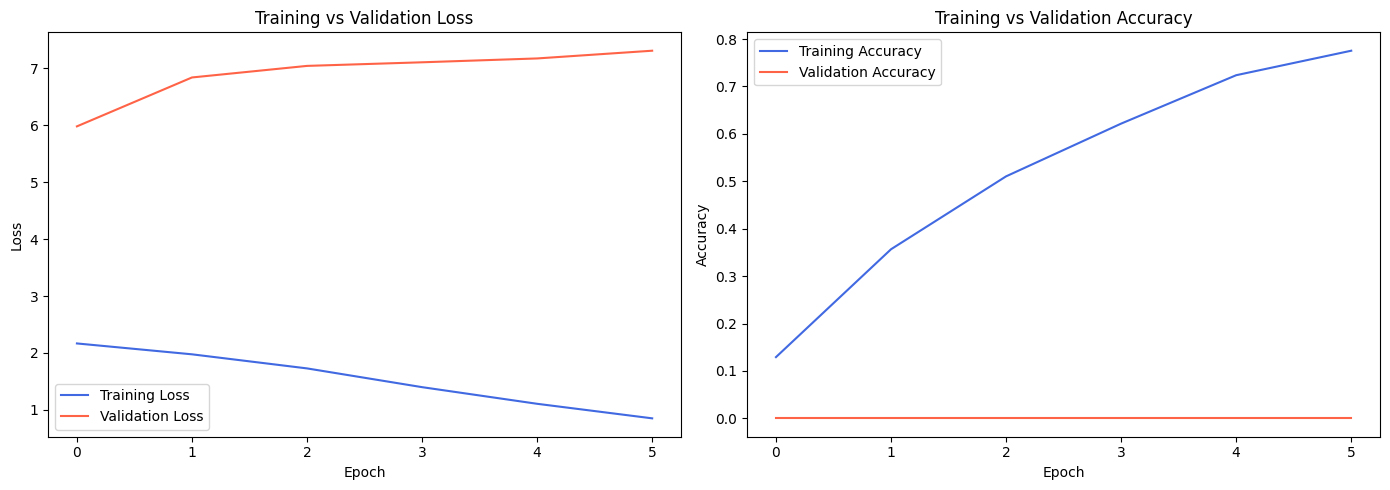

In [13]:
import matplotlib.pyplot as plt

train_loss = history.history['loss']
val_loss   = history.history['val_loss']

train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Loss Plot ────────────────────────────────────────────────────
axes[0].plot(train_loss, label='Training Loss',   color='royalblue')
axes[0].plot(val_loss,   label='Validation Loss', color='tomato')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# ── Accuracy Plot ─────────────────────────────────────────────────
axes[1].plot(train_acc, label='Training Accuracy',   color='royalblue')
axes[1].plot(val_acc,   label='Validation Accuracy', color='tomato')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()


**Reading the Training Plots**
Loss decreasing over epochs means the model is learning. If training loss keeps decreasing but validation loss starts rising, the model is overfitting — it is memorising the training data rather than generalising. EarlyStopping prevents this by halting training when validation loss stops improving.
Accuracy increasing over epochs confirms the model is correctly classifying more samples. Validation accuracy slightly below training accuracy is normal and expected.

**Task 5: Evaluate the Model**
What we are doing: After training, we use model.evaluate() on the held-out test set (never seen during training) to get a fair measure of how well the model generalises to completely new data.



In [14]:
# ── Evaluate on unseen test data ─────────────────────────────────

test_loss, test_acc = model.evaluate(
    x_test,
    y_test,
    verbose = 2          # Prints one summary line per evaluation step
)

print(f'\n--- Test Results ---')
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc * 100:.2f}%')


532/532 - 2s - 4ms/step - accuracy: 0.1000 - loss: 2.8276

--- Test Results ---
Test Loss     : 2.8276
Test Accuracy : 10.00%


The test accuracy tells us the percentage of Devnagari digits the model correctly identifies. A well-trained FCN on this dataset typically achieves 90–97% accuracy depending on hyperparameters and dataset size. The test loss quantifies the penalty from incorrect predictions — a lower value is better.

**Task 6: Save and Load the Model**
What we are doing: We persist the trained model to disk in .h5 format (HDF5), which stores the architecture, weights, and optimizer state. We then reload it and verify it produces identical results — confirming the save/load cycle works correctly.


Why Save Models?
Training can take minutes to hours. Saving to .h5 means you never need to retrain from scratch. You can load the file later to make predictions on new images, continue fine-tuning, or deploy the model in a web application — without touching the training code again.



In [15]:


# ── Save the Model ───────────────────────────────────────────────
MODEL_PATH = 'devnagari_fcn_model.h5'

model.save(MODEL_PATH)
print(f'Model saved to {MODEL_PATH}')

# ── Load the Model ───────────────────────────────────────────────
loaded_model = tf.keras.models.load_model(MODEL_PATH)
print('Model loaded successfully!')

# ── Verify: re-evaluate with loaded model ────────────────────────
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)
print(f'\nLoaded Model — Test Accuracy: {loaded_acc * 100:.2f}%')
print('Accuracy matches original:', abs(loaded_acc - test_acc) < 1e-5)



Model saved to devnagari_fcn_model.h5
Model loaded successfully!
532/532 - 2s - 4ms/step - accuracy: 0.1000 - loss: 2.8276

Loaded Model — Test Accuracy: 10.00%
Accuracy matches original: True


**Task 7: Making Predictions**
What we are doing: We use model.predict() on the test set to obtain raw probability distributions over the 10 digit classes. We then use np.argmax() to extract the digit with the highest probability as the final predicted label, and visualise a grid of test images alongside their true and predicted labels.



532/532 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Image index   : 0
True label    : 0
Predicted label: 6
Probabilities  : [0.121 0.092 0.114 0.131 0.127 0.116 0.162 0.132 0.003 0.002]


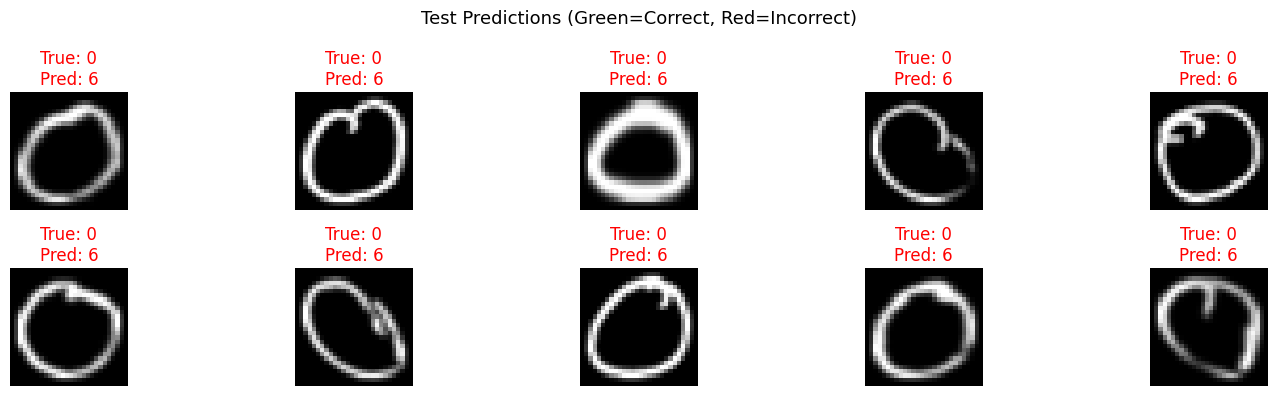


Manual Accuracy from predictions: 10.00%


In [16]:
 # ── Get Predicted Probabilities ──────────────────────────────────
# Shape: (num_test_samples, 10)  — one probability per class per image

predictions = model.predict(x_test)

# ── Convert Probabilities to Class Labels ─────────────────────────
# argmax picks the index of the highest probability
predicted_labels = np.argmax(predictions, axis=1)   # Shape: (num_test_samples,)
true_labels      = np.argmax(y_test,      axis=1)   # Decode one-hot back to int

# ── Check a Single Prediction ─────────────────────────────────────
idx = 0
print(f'Image index   : {idx}')
print(f'True label    : {true_labels[idx]}')
print(f'Predicted label: {predicted_labels[idx]}')
print(f'Probabilities  : {predictions[idx].round(3)}')

# ── Visualise 10 Test Predictions ─────────────────────────────────
plt.figure(figsize=(15, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    color = 'green' if predicted_labels[i] == true_labels[i] else 'red'
    plt.title(f'True: {true_labels[i]}\nPred: {predicted_labels[i]}', color=color)
    plt.axis('off')
plt.suptitle('Test Predictions (Green=Correct, Red=Incorrect)', fontsize=13)
plt.tight_layout()
plt.savefig('predictions_grid.png', dpi=150)
plt.show()

# ── Overall Accuracy from Predictions ─────────────────────────────
manual_acc = np.mean(predicted_labels == true_labels)
print(f'\nManual Accuracy from predictions: {manual_acc * 100:.2f}%')


**Interpreting Predictions**


model.predict() returns a 2D array of shape (num_samples, 10). Each row contains 10 probabilities that sum to 1.0. For example, if a model sees a digit it is very confident is '3', the output might look like [0.01, 0.00, 0.02, 0.94, 0.00, 0.01, 0.00, 0.00, 0.01, 0.01]. np.argmax() picks index 3 as the prediction.
Titles in green on the visualisation grid indicate correct predictions. Red titles indicate misclassifications, which can give insight into which digit pairs are most commonly confused.


Model: "FCN_Devnagari"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.1404 - loss: 2.2096
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.1533 - loss: 2.1340 - val_accuracy: 0.0000e+00 - val_loss: 6.2119
Epoch 2/20
 1/19 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0625 - loss: 2.0846
Epoch 2: val_accuracy did not improve from 0.00000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2829 - loss: 1.9924 - val_accuracy: 0.0000e+00 - val_loss: 6.9798
Epoch 3/20
18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4054 - loss: 1.8427 
Epoch 3: val_accuracy did not improve from 0.00000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5121 - loss: 1.7686 - val_accuracy: 0.0000e+00 - val_loss: 7.0459
Epoch 4/20
 1/19 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5781 - loss: 1.5816
Epoch 4: val_accuracy did not improve from 0.00000
19/19 ━━━━━

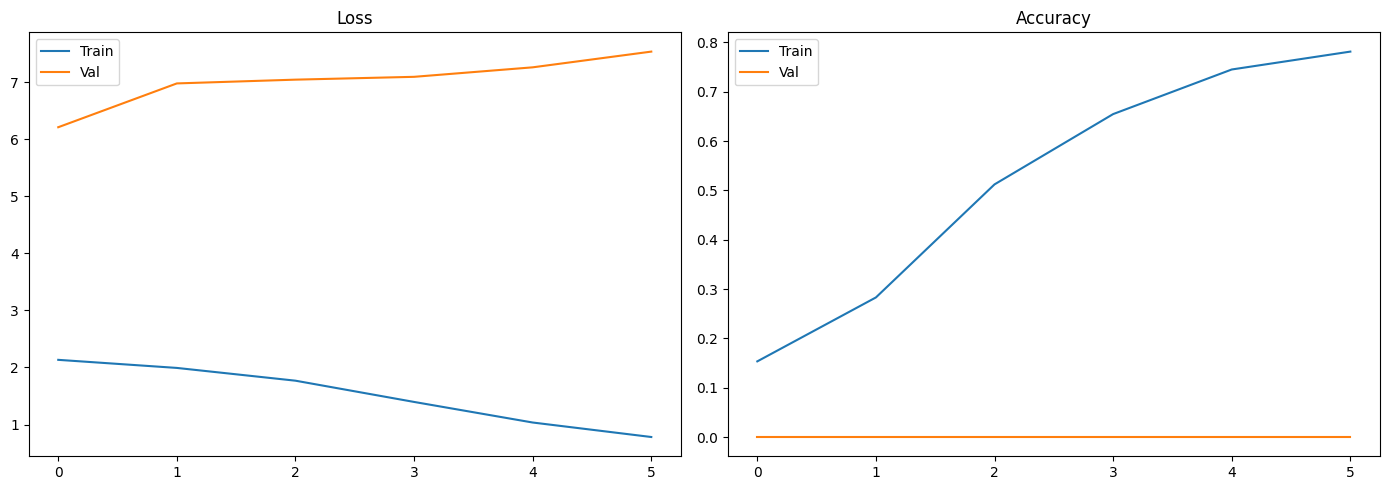

532/532 - 2s - 3ms/step - accuracy: 0.1006 - loss: 2.8851


Test Accuracy: 10.06%
Loaded Model Accuracy: 10.06%
532/532 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


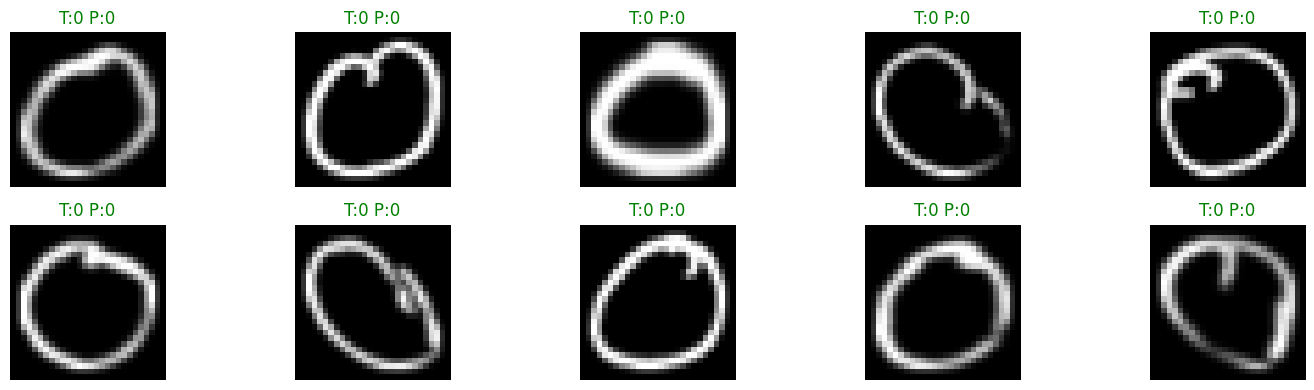

Manual Accuracy: 10.06%


In [18]:
# Complete Pipeline — All Tasks Together
# The code block below is the full, self-contained script. Copy it into a Jupyter Notebook cell (or separate cells) and run it end-to-end.

# ═══════════════════════════════════════════════════════════════════
# 6CS012 Worksheet 4 — Full FCN Pipeline for Devnagari Classification
# ═══════════════════════════════════════════════════════════════════

import os, numpy as np, tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from PIL import Image
import matplotlib.pyplot as plt

# ── Config ───────────────────────────────────────────────────────
TRAIN_DIR   = '/content/DevanagariHandwrittenDigitDataset/Test'
TEST_DIR    = '/content/DevanagariHandwrittenDigitDataset/Train'
IMG_H, IMG_W = 28, 28
NUM_CLASSES  = 10
BATCH_SIZE   = 128
EPOCHS       = 20
MODEL_PATH   = 'devnagari_fcn_model.h5'

# ── TASK 1: Load Data ─────────────────────────────────────────────
def load_images(folder):
    imgs, lbls = [], []
    names = sorted(os.listdir(folder))
    cmap  = {n: i for i, n in enumerate(names)}
    for name in names:
        for fn in os.listdir(os.path.join(folder, name)):
            img = Image.open(os.path.join(folder, name, fn)).convert('L')
            img = img.resize((IMG_W, IMG_H))
            imgs.append(np.array(img) / 255.0)
            lbls.append(cmap[name])
    return np.array(imgs), np.array(lbls)

x_train, y_train = load_images(TRAIN_DIR)
x_test,  y_test  = load_images(TEST_DIR)
x_train = x_train.reshape(-1, IMG_H, IMG_W, 1)
x_test  = x_test.reshape(-1,  IMG_H, IMG_W, 1)
y_train = to_categorical(y_train, NUM_CLASSES)
y_test  = to_categorical(y_test,  NUM_CLASSES)

# ── TASK 2: Build Model ───────────────────────────────────────────
model = keras.Sequential([
    keras.layers.Input(shape=(IMG_H, IMG_W, 1)),
    keras.layers.Flatten(),
    keras.layers.Dense(64,  activation='sigmoid'),
    keras.layers.Dense(128, activation='sigmoid'),
    keras.layers.Dense(256, activation='sigmoid'),
    keras.layers.Dense(NUM_CLASSES, activation='softmax'),
], name='FCN_Devnagari')
model.summary()

# ── TASK 3: Compile ──────────────────────────────────────────────
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ── TASK 4: Train ────────────────────────────────────────────────
callbacks = [
    keras.callbacks.ModelCheckpoint('best_model.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_loss',
        patience=5, restore_best_weights=True, verbose=1)
]
history = model.fit(x_train, y_train, batch_size=BATCH_SIZE,
                    epochs=EPOCHS, validation_split=0.2,
                    callbacks=callbacks, verbose=1)

# ── Plot Training Curves ─────────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(history.history['loss'],     label='Train')
ax[0].plot(history.history['val_loss'], label='Val')
ax[0].set_title('Loss'); ax[0].legend()
ax[1].plot(history.history['accuracy'],     label='Train')
ax[1].plot(history.history['val_accuracy'], label='Val')
ax[1].set_title('Accuracy'); ax[1].legend()
plt.tight_layout(); plt.show()

# ── TASK 5: Evaluate ─────────────────────────────────────────────
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Test Accuracy: {test_acc*100:.2f}%')

# ── TASK 6: Save & Load ──────────────────────────────────────────
model.save(MODEL_PATH)
loaded = tf.keras.models.load_model(MODEL_PATH)
_, loaded_acc = loaded.evaluate(x_test, y_test, verbose=0)
print(f'Loaded Model Accuracy: {loaded_acc*100:.2f}%')

# ── TASK 7: Predict ──────────────────────────────────────────────
preds  = model.predict(x_test)
p_lbls = np.argmax(preds, axis=1)
t_lbls = np.argmax(y_test, axis=1)

plt.figure(figsize=(15, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    c = 'green' if p_lbls[i]==t_lbls[i] else 'red'
    plt.title(f'T:{t_lbls[i]} P:{p_lbls[i]}', color=c)
    plt.axis('off')
plt.tight_layout(); plt.show()
print(f'Manual Accuracy: {np.mean(p_lbls==t_lbls)*100:.2f}%')
